Ukuran Data: (244, 9)

Statistik Data (Dalam Rupiah):
       total_bill_rp    tip_rp
count          244.0     244.0
mean        350211.0   53070.0
std         157573.0   24490.0
min          54339.0   17700.0
25%         236251.0   35400.0
50%         314972.0   51330.0
75%         427057.0   63056.0
max         899337.0  177000.0


/tmp/ipykernel_10890/3757398004.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_per_day = df.groupby('day')['total_bill_rp'].mean()


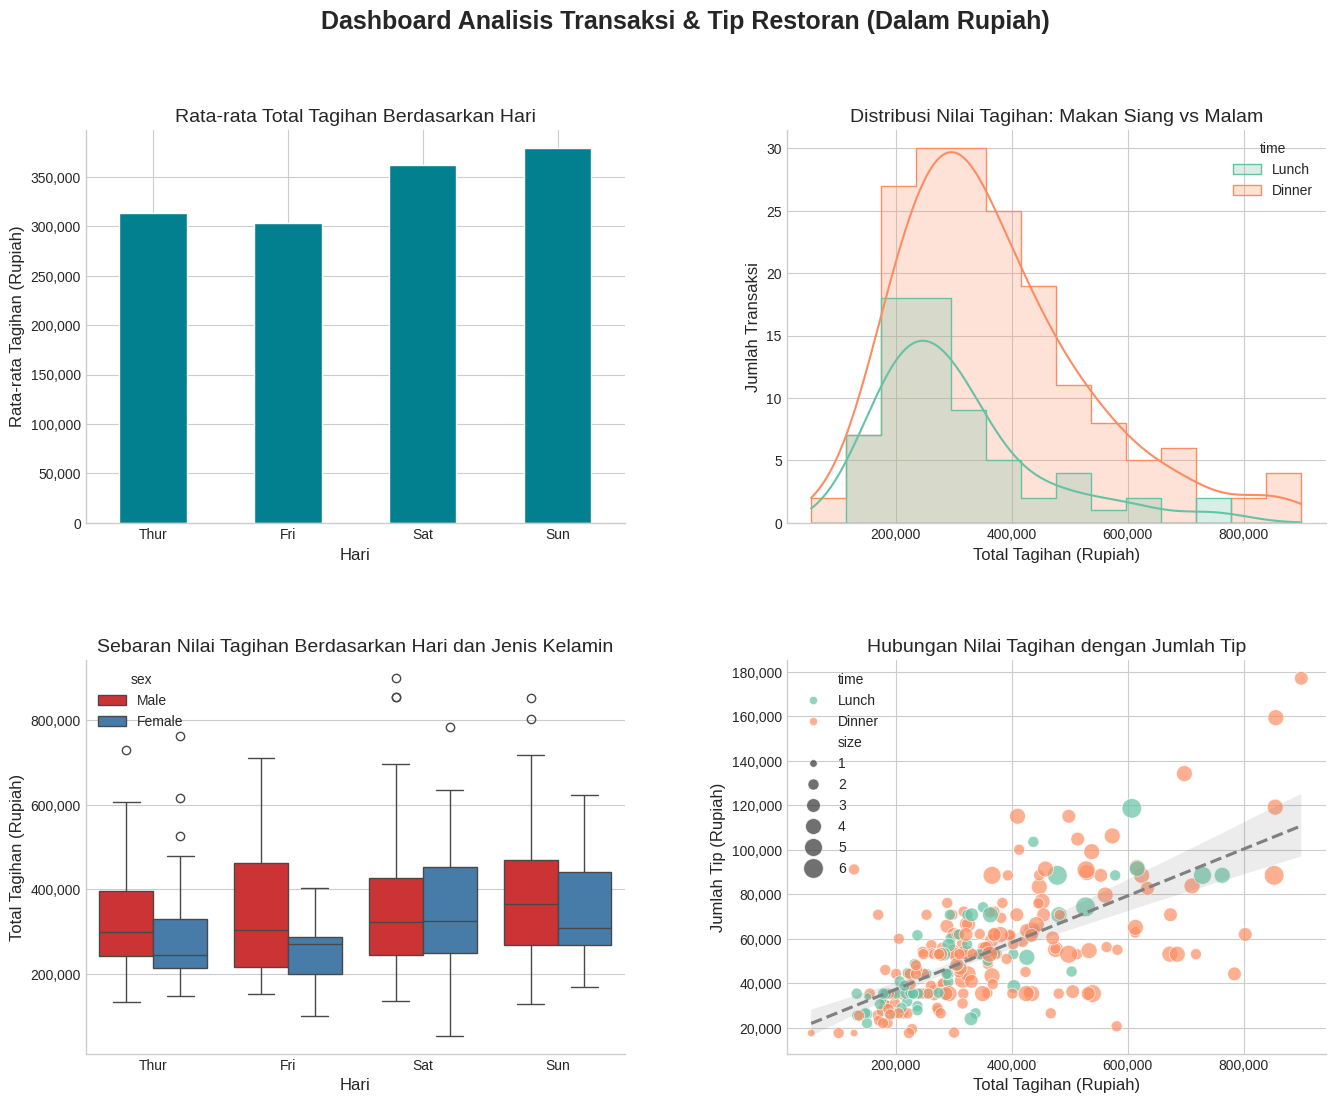

Dashboard Transaksi dan Tip'


In [1]:
# =========================================================
# HASTA SATRIYA - 240401010207_IF403
# ==============================================
# TUGAS PERTEMUAN 5 - VISUALISASI DATA (RUPIAH)
# ==============================================

# 1. Import Library
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 2. Load Dataset & KONVERSI KE RUPIAH
df = sns.load_dataset('tips')

# 🔑 KONVERSI: Ubah Dolar ke Rupiah (Asumsi Kurs 1 USD = Rp 17.700)
KURS = 17700
df['total_bill_rp'] = df['total_bill'] * KURS
df['tip_rp'] = df['tip'] * KURS

print("Ukuran Data:", df.shape)
print("\nStatistik Data (Dalam Rupiah):")
print(df[['total_bill_rp', 'tip_rp']].describe().round(0)) # Dibulatkan ke ribuan

# 3. Setup Layout Dashboard (2 Baris x 2 Kolom)
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Transaksi & Tip Restoran (Dalam Rupiah)', fontsize=18, fontweight='bold', y=0.98)

# Atur jarak antar grafik
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Buat tempat untuk setiap grafik
ax1 = fig.add_subplot(gs[0, 0])  # Kiri Atas
ax2 = fig.add_subplot(gs[0, 1])  # Kanan Atas
ax3 = fig.add_subplot(gs[1, 0])  # Kiri Bawah
ax4 = fig.add_subplot(gs[1, 1])  # Kanan Bawah

# ==============================================
# GRAFIK 1: Bar Chart - Rata-rata Tagihan per Hari
# ==============================================
avg_per_day = df.groupby('day')['total_bill_rp'].mean()
avg_per_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')

# Kustomisasi tampilan
ax1.set_title('Rata-rata Total Tagihan Berdasarkan Hari', fontsize=14)
ax1.set_xlabel('Hari', fontsize=12)
ax1.set_ylabel('Rata-rata Tagihan (Rupiah)', fontsize=12)

# Format sumbu Y agar ada titik ribuannya
ax1.ticklabel_format(style='plain', axis='y')
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# ==============================================
# GRAFIK 2: Histogram + KDE - Distribusi Tagihan
# ==============================================
sns.histplot(
    data=df,
    x='total_bill_rp',  # <-- Pakai kolom Rupiah
    hue='time',
    kde=True,
    palette='Set2',
    element='step',
    ax=ax2
)

ax2.set_title('Distribusi Nilai Tagihan: Makan Siang vs Malam', fontsize=14)
ax2.set_xlabel('Total Tagihan (Rupiah)', fontsize=12)
ax2.set_ylabel('Jumlah Transaksi', fontsize=12)

# Format sumbu X agar mudah dibaca
ax2.ticklabel_format(style='plain', axis='x')
ax2.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax2.spines[['top', 'right']].set_visible(False)

# ==============================================
# GRAFIK 3: Boxplot - Distribusi Tagihan per Hari & Gender
# ==============================================
sns.boxplot(
    data=df,
    x='day',
    y='total_bill_rp', # <-- Pakai kolom Rupiah
    hue='sex',
    palette='Set1',
    ax=ax3
)

ax3.set_title('Sebaran Nilai Tagihan Berdasarkan Hari dan Jenis Kelamin', fontsize=14)
ax3.set_xlabel('Hari', fontsize=12)
ax3.set_ylabel('Total Tagihan (Rupiah)', fontsize=12)

# Format sumbu Y
ax3.ticklabel_format(style='plain', axis='y')
ax3.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax3.spines[['top', 'right']].set_visible(False)

# ==============================================
# GRAFIK 4: Scatter Plot - Hubungan Tagihan dan Tip
# ==============================================
sns.scatterplot(
    data=df,
    x='total_bill_rp', # <-- Pakai kolom Rupiah
    y='tip_rp',        # <-- Pakai kolom Rupiah
    hue='time',
    size='size',
    sizes=(30, 200),
    alpha=0.7,
    palette='Set2',
    ax=ax4
)

# Tambahkan garis tren regresi
sns.regplot(
    data=df,
    x='total_bill_rp',
    y='tip_rp',
    scatter=False,
    color='gray',
    line_kws={'linestyle':'--'},
    ax=ax4
)

ax4.set_title('Hubungan Nilai Tagihan dengan Jumlah Tip', fontsize=14)
ax4.set_xlabel('Total Tagihan (Rupiah)', fontsize=12)
ax4.set_ylabel('Jumlah Tip (Rupiah)', fontsize=12)

# Format sumbu X dan Y
ax4.ticklabel_format(style='plain', axis='both')
ax4.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax4.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax4.spines[['top', 'right']].set_visible(False)

# ==============================================
# Simpan & Tampilkan Hasil
# ==============================================
plt.savefig('dashboard_tugas5_rupiah.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard Transaksi dan Tip'")